<a href="https://colab.research.google.com/github/Swastika-IT/yolodevs/blob/main/og.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

print("Please select the file to upload.")
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))


Please select the file to upload.


Saving Rice-Quality 3.v4i.yolov12-zip.zip to Rice-Quality 3.v4i.yolov12-zip.zip
User uploaded file "Rice-Quality 3.v4i.yolov12-zip.zip" with length 15676768 bytes


In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 85.8 MB/s eta 0:00:00


In [ ]:
import zipfile

zip_path="Rice-Quality 3.v4i.yolov12-zip.zip"

with zipfile.ZipFile(zip_path,'r') as zip_ref:
    zip_ref.extractall()

print("done")

done


In [ ]:
import os

os.listdir()

['.config',
 'README.roboflow.txt',
 'train',
 'valid',
 'README.dataset.txt',
 'data.yaml',
 'test',
 'Rice-Quality 3.v4i.yolov12-zip.zip',
 'sample_data']

In [ ]:
from ultralytics import YOLO

model=YOLO("yolo26n.pt")

print(model.model)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C3k2(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=

In [ ]:
model.train(
    data="data.yaml",
    epochs=300,
    imgsz=640,
    batch=12
)

Ultralytics 8.4.61 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=12, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=300, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, p

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e1df9ef7fb0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,

In [ ]:
import os

os.listdir("/content/runs/detect/train/weights")

['last.pt', 'best.pt']

In [ ]:
model=YOLO("/content/runs/detect/train/weights/best.pt")

results=model.predict(

source="/content/test/images",

save=True,

conf=0.25

)


image 1/15 /content/test/images/1700059259412_jpg.rf.9b7e77ba9ea81ea1a3e3d577e41cba9e.jpg: 640x640 2 broken-chalkys, 1 broken-clear, 13 sounds, 2 unsounds, 3 whole-chalkys, 12.2ms
image 2/15 /content/test/images/1700325971094_jpg.rf.3dbb3070c6db27272d97687b686c6a0f.jpg: 640x640 6 broken-chalkys, 1 broken-clear, 6 sounds, 5 unsounds, 7 whole-chalkys, 9.7ms
image 3/15 /content/test/images/20-35-56_c691e2c0_jpg.rf.36f6f2760946542cdcc7110cd5deecd7.jpg: 640x640 13 broken-chalkys, 10 broken-clears, 6 sounds, 6 whole-chalkys, 10.9ms
image 4/15 /content/test/images/NewItem107_png.rf.c2980816e86cd98023643f4446463a23.jpg: 640x640 2 broken-clears, 20 sounds, 10 unsounds, 9.6ms
image 5/15 /content/test/images/c7_jpg.rf.5e750055545c845089b04f5adf254443.jpg: 640x640 7 broken-chalkys, 4 broken-clears, 25 sounds, 8 stones, 25 whole-chalkys, 16.6ms
image 6/15 /content/test/images/d5_jpg.rf.ba0214521ce5d5825e041bc2a0cddf52.jpg: 640x640 1 broken-chalky, 19 broken-clears, 9 plastics, 85 sounds, 1 stone, 

In [ ]:
import os

os.listdir("/content/runs/detect/predict")

['c7_jpg.rf.5e750055545c845089b04f5adf254443.jpg',
 'NewItem107_png.rf.c2980816e86cd98023643f4446463a23.jpg',
 'rp1_jpg.rf.7698f9544abcd0df83e8f501c04523c5.jpg',
 'rpk6_jpg.rf.53d298cdc8134d6649f5df568b0b08fe.jpg',
 'rr3_jpg.rf.fe4d7e34c0c70abb5d1760e2ab6d74d8.jpg',
 'd5_jpg.rf.ba0214521ce5d5825e041bc2a0cddf52.jpg',
 'r1_jpg.rf.381aee4cc9cf89889835e18ba7efcc75.jpg',
 'ds4_jpg.rf.2155bb587d205d9dbfe149eee40ac121.jpg',
 '1700059259412_jpg.rf.9b7e77ba9ea81ea1a3e3d577e41cba9e.jpg',
 'vidd_mp4-0000_jpg.rf.ded5d7184bd46fab6f9fa90bdf6dfcf6.jpg',
 '20-35-56_c691e2c0_jpg.rf.36f6f2760946542cdcc7110cd5deecd7.jpg',
 'rpk3_jpg.rf.e96f9597f310ac0367027c9f222add95.jpg',
 '1700325971094_jpg.rf.3dbb3070c6db27272d97687b686c6a0f.jpg',
 'vidd6_mp4-0003_jpg.rf.9207257a3bfe03f05e6ba1fa28fc8d21.jpg',
 'r2_jpg.rf.694d80d6549587623b10e94e9f30f7dc.jpg']

(np.float64(-0.5), np.float64(639.5), np.float64(639.5), np.float64(-0.5))

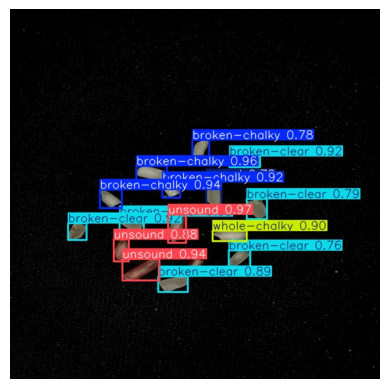

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img=Image.open(
"/content/runs/detect/predict/rp1_jpg.rf.7698f9544abcd0df83e8f501c04523c5.jpg"
)

plt.imshow(img)

plt.axis("off")

In [ ]:
metrics = model.val()

Ultralytics 8.4.61 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1916.0±377.0 MB/s, size: 78.3 KB)
val: Scanning /content/valid/labels.cache... 14 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 14/14 4.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.8it/s 0.5s
                   all         14        595      0.841       0.82      0.884      0.784
         broken-chalky          9         16      0.696       0.75      0.819      0.763
          broken-clear         11         83      0.868      0.819      0.925       0.81
        foreign-object          3         22      0.736      0.818       0.87      0.764
               plastic          7         37      0.941      0.866      0.921      0.757
                 sound         13        195      0.803      0.913        0.9      0.803
                 stone          7         40       0.9

In [ ]:
metrics=model.val(
save_json=True
)

Ultralytics 8.4.61 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1993.1±756.8 MB/s, size: 53.6 KB)
val: Scanning /content/valid/labels.cache... 14 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 14/14 4.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.8it/s 0.5s
                   all         14        595      0.841       0.82      0.884      0.784
         broken-chalky          9         16      0.696       0.75      0.819      0.763
          broken-clear         11         83      0.868      0.819      0.925       0.81
        foreign-object          3         22      0.736      0.818       0.87      0.764
               plastic          7         37      0.941      0.866      0.921      0.757
                 sound         13        195      0.803      0.913        0.9      0.803
                 stone          7         40       0.9

In [ ]:
print(metrics.box.map)

print(metrics.box.map50)

print(metrics.box.mp)

print(metrics.box.mr)

0.7838770779652339
0.8842695344251787
0.84059403391005
0.8204068603645471


In [ ]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train/weights/best.pt")

In [ ]:
results = model.predict(

source="/content/test/images",

save=True,

conf=0.25,

show=False

)


image 1/15 /content/test/images/1700059259412_jpg.rf.9b7e77ba9ea81ea1a3e3d577e41cba9e.jpg: 640x640 2 broken-chalkys, 1 broken-clear, 13 sounds, 2 unsounds, 3 whole-chalkys, 13.9ms
image 2/15 /content/test/images/1700325971094_jpg.rf.3dbb3070c6db27272d97687b686c6a0f.jpg: 640x640 6 broken-chalkys, 1 broken-clear, 6 sounds, 5 unsounds, 7 whole-chalkys, 10.0ms
image 3/15 /content/test/images/20-35-56_c691e2c0_jpg.rf.36f6f2760946542cdcc7110cd5deecd7.jpg: 640x640 13 broken-chalkys, 10 broken-clears, 6 sounds, 6 whole-chalkys, 9.8ms
image 4/15 /content/test/images/NewItem107_png.rf.c2980816e86cd98023643f4446463a23.jpg: 640x640 2 broken-clears, 20 sounds, 10 unsounds, 10.4ms
image 5/15 /content/test/images/c7_jpg.rf.5e750055545c845089b04f5adf254443.jpg: 640x640 7 broken-chalkys, 4 broken-clears, 25 sounds, 8 stones, 25 whole-chalkys, 10.2ms
image 6/15 /content/test/images/d5_jpg.rf.ba0214521ce5d5825e041bc2a0cddf52.jpg: 640x640 1 broken-chalky, 19 broken-clears, 9 plastics, 85 sounds, 1 stone,

In [ ]:
import os

os.listdir("/content/runs/detect/predict")

['c7_jpg.rf.5e750055545c845089b04f5adf254443.jpg',
 'NewItem107_png.rf.c2980816e86cd98023643f4446463a23.jpg',
 'rp1_jpg.rf.7698f9544abcd0df83e8f501c04523c5.jpg',
 'rpk6_jpg.rf.53d298cdc8134d6649f5df568b0b08fe.jpg',
 'rr3_jpg.rf.fe4d7e34c0c70abb5d1760e2ab6d74d8.jpg',
 'd5_jpg.rf.ba0214521ce5d5825e041bc2a0cddf52.jpg',
 'r1_jpg.rf.381aee4cc9cf89889835e18ba7efcc75.jpg',
 'ds4_jpg.rf.2155bb587d205d9dbfe149eee40ac121.jpg',
 '1700059259412_jpg.rf.9b7e77ba9ea81ea1a3e3d577e41cba9e.jpg',
 'vidd_mp4-0000_jpg.rf.ded5d7184bd46fab6f9fa90bdf6dfcf6.jpg',
 '20-35-56_c691e2c0_jpg.rf.36f6f2760946542cdcc7110cd5deecd7.jpg',
 'rpk3_jpg.rf.e96f9597f310ac0367027c9f222add95.jpg',
 '1700325971094_jpg.rf.3dbb3070c6db27272d97687b686c6a0f.jpg',
 'vidd6_mp4-0003_jpg.rf.9207257a3bfe03f05e6ba1fa28fc8d21.jpg',
 'r2_jpg.rf.694d80d6549587623b10e94e9f30f7dc.jpg']

In [ ]:
results=model.predict(

source="/content/test/images",

save=True

)

for r in results:

    print(r.boxes.cls)

    print(r.boxes.conf)


image 1/15 /content/test/images/1700059259412_jpg.rf.9b7e77ba9ea81ea1a3e3d577e41cba9e.jpg: 640x640 2 broken-chalkys, 1 broken-clear, 13 sounds, 2 unsounds, 3 whole-chalkys, 18.7ms
image 2/15 /content/test/images/1700325971094_jpg.rf.3dbb3070c6db27272d97687b686c6a0f.jpg: 640x640 6 broken-chalkys, 1 broken-clear, 6 sounds, 5 unsounds, 7 whole-chalkys, 10.8ms
image 3/15 /content/test/images/20-35-56_c691e2c0_jpg.rf.36f6f2760946542cdcc7110cd5deecd7.jpg: 640x640 13 broken-chalkys, 10 broken-clears, 6 sounds, 6 whole-chalkys, 15.9ms
image 4/15 /content/test/images/NewItem107_png.rf.c2980816e86cd98023643f4446463a23.jpg: 640x640 2 broken-clears, 20 sounds, 10 unsounds, 10.3ms
image 5/15 /content/test/images/c7_jpg.rf.5e750055545c845089b04f5adf254443.jpg: 640x640 7 broken-chalkys, 4 broken-clears, 25 sounds, 8 stones, 25 whole-chalkys, 10.3ms
image 6/15 /content/test/images/d5_jpg.rf.ba0214521ce5d5825e041bc2a0cddf52.jpg: 640x640 1 broken-chalky, 19 broken-clears, 9 plastics, 85 sounds, 1 stone

In [2]:
!git clone https://github.com/Swastika-IT/yolodevs.git

Cloning into 'yolodevs'...
remote: Enumerating objects: 1112, done.
remote: Counting objects: 100% (1112/1112), done.
remote: Compressing objects: 100% (879/879), done.
remote: Total 1112 (delta 215), reused 1112 (delta 215), pack-reused 0 (from 0)
Receiving objects: 100% (1112/1112), 2.58 MiB | 7.05 MiB/s, done.
Resolving deltas: 100% (215/215), done.


In [3]:
!ls

sample_data  yolodevs
